# <b>Sales Forecasting Project - EDA</b>

##  Objectives 

This project aims to develop a **Sales Forecasting System** powered by data analysis and machine learning techniques, in order to achieve the following objectives:

* **Analyze historical data** related to sales, customers, and discounts to uncover hidden patterns and relationships.
* **Support managerial decision-making** by providing insights that help anticipate demand, manage inventory, and optimize pricing strategies.
* **Address influencing factors** such as discounts, seasonality, and different sales periods (monthly, quarterly, yearly).
* **Build a Real-Time Forecasting Model** that can accurately predict future sales.
* **Improve operational efficiency** and reduce risks associated with inaccurate sales estimations.


# Section 1: Import Libraries
----------- ------------
##### Add any other libraries you need (XGBoost, Prophet, LightGBM, etc.)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Section 2: Load Dataset
----------- ------------

In [ ]:
# 1. Load the dataset
file_path = "car_sales_2018_2024_Cleaned.csv"
df = pd.read_csv(file_path)

# Section 4: Exploratory Data Analysis (EDA)
----------- ------------
#### - Basic statistics
#### - Visualizations (trends, seasonality, correlations,...)


### Estimating Future Demand (Lag Features)
A powerful feature for forecasting inventory needs based on historical demand.

In [ ]:
# Aggregate past sales per Car Make & Model per Month
monthly_sales = (
    df.groupby(["Car Make", "Car Model", "Sale Month Num"])["Quantity"]
    .sum()
    .reset_index()
)
monthly_sales.rename(columns={"Quantity": "Monthly Demand"}, inplace=True)

In [ ]:
top_cars_per_month = monthly_sales.loc[
    monthly_sales.groupby("Sale Month Num")["Monthly Demand"].idxmax()
]
top_cars_per_month = top_cars_per_month.sort_values("Sale Month Num")
print(top_cars_per_month)

     Car Make   Car Model  Sale Month Num  Monthly Demand
1032   Toyota       Prius               1          5075.0
421   Hyundai      Tucson               2          2544.0
770    Toyota       Camry               3          2807.0
771    Toyota       Camry               4          2654.0
796    Toyota     Corolla               5          2766.0
1073   Toyota        RAV4               6          2738.0
1038   Toyota       Prius               7          2779.0
931    Toyota  Highlander               8          2795.0
776    Toyota       Camry               9          2671.0
1041   Toyota       Prius              10          2794.0
1078   Toyota        RAV4              11          2643.0
779    Toyota       Camry              12          2869.0


<b>Potential Insights:</b>

- Predict inventory requirements for the next month based on the previous month's sales.

- Identify trends for specific car models.

### Profitability by Discount Bracket
- Identify the optimal discount level for maximizing profitability.
- Actionable Improvement: Fine-tune discount strategies for different car models or seasons.


In [ ]:
# Create discount bins
df["Discount_Bracket"] = pd.cut(
    df["Discount"],
    bins=[0, 0.05, 0.1, 0.2, 0.5, 1],
    labels=["0-5%", "5-10%", "10-20%", "20-50%", "50%+"],
    include_lowest=True,
)
profit_by_discount = df.groupby("Discount_Bracket")["Profit"].mean()
print(profit_by_discount)

Discount_Bracket
0-5%      15768.212585
5-10%     16009.371645
10-20%    21966.391752
20-50%             NaN
50%+               NaN
Name: Profit, dtype: float64


C:\Users\kira\AppData\Local\Temp\ipykernel_14428\3403411952.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profit_by_discount = df.groupby('Discount_Bracket')['Profit'].mean()


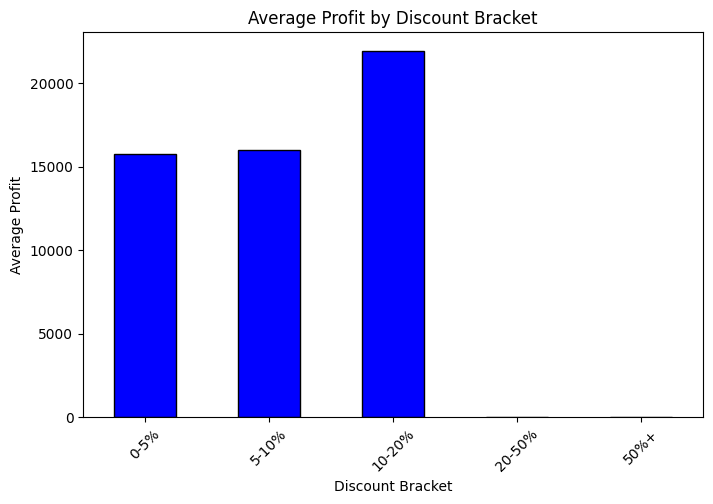

In [ ]:
profit_by_discount.plot(kind="bar", figsize=(8, 5), color="blue", edgecolor="k")

plt.title("Average Profit by Discount Bracket")
plt.xlabel("Discount Bracket")
plt.ylabel("Average Profit")
plt.xticks(rotation=45)
plt.show()

<b>Insight:</b> 
Most sales happen within the 0–20% discount range. Interestingly, the 10–20% discount bracket generates the highest profit, which suggests that slightly higher discounts encourage more purchases and increase overall profitability. Since there are no sales recorded in the 20–50% or 50%+ brackets, it seems the dealership rarely (if ever) gives such large discounts. This indicates that targeted promotions in the 10–20% discount range could be an effective strategy to boost sales while maintaining strong profit margins.

### Seasonal Demand Analysis
- Identify which season sees the highest total sales volume.
- Actionable Improvement: Ramp up marketing campaigns and inventory before peak seasons.

In [ ]:
seasonal_demand = df.groupby("Season")[
    "Quantity"
].sum()  # Using sum to see total volume per season
print(seasonal_demand)

Season
Fall      388245.0
Spring    497029.0
Summer    391781.0
Winter    386285.0
Name: Quantity, dtype: float64


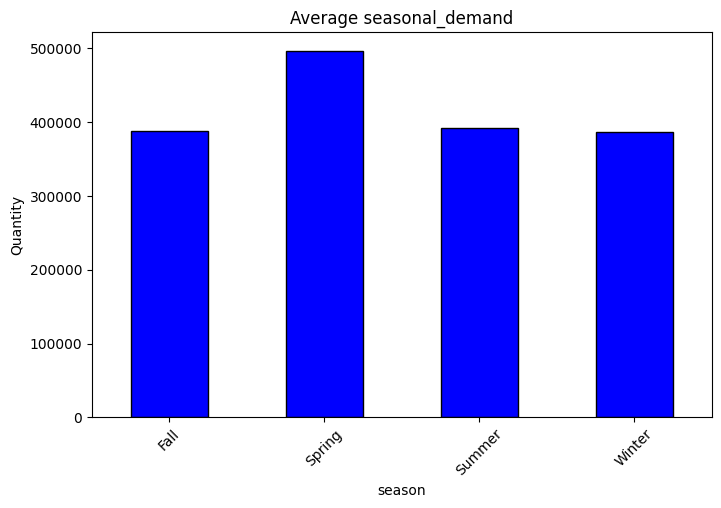

In [ ]:
seasonal_demand.plot(kind="bar", figsize=(8, 5), color="blue", edgecolor="k")

plt.title("Average seasonal_demand")
plt.xlabel("season")
plt.ylabel("Quantity")
plt.xticks(rotation=45)
plt.show()

<b>Insight:</b> 

Car sales peak in Spring, suggesting higher customer demand during this season. The dealership could consider aligning promotions, marketing campaigns, and stock availability to maximize sales in Spring.

### Brand (Make) Performance: Sales vs. Profit
- Compare car brands based on their average sales quantity and total profit contribution.
- Actionable Improvement: Focus inventory and marketing efforts on the most profitable and popular brands.

In [ ]:
make_performance = df.groupby("Car Make").agg(
    Quantity=("Quantity", "sum"), Total_Profit=("Profit", "sum")
)
print(make_performance.sort_values("Total_Profit", ascending=False))

           Quantity  Total_Profit
Car Make                         
Bmw        129720.0  1.792236e+09
Mercedes   114236.0  1.758453e+09
Audi       134896.0  1.754714e+09
Toyota     272148.0  1.709092e+09
Ford       165563.0  1.358582e+09
Chevrolet  168792.0  1.215324e+09
Honda      169586.0  9.924381e+08
Nissan     169181.0  9.576776e+08
Hyundai    170349.0  8.978239e+08
Kia        168869.0  8.801367e+08


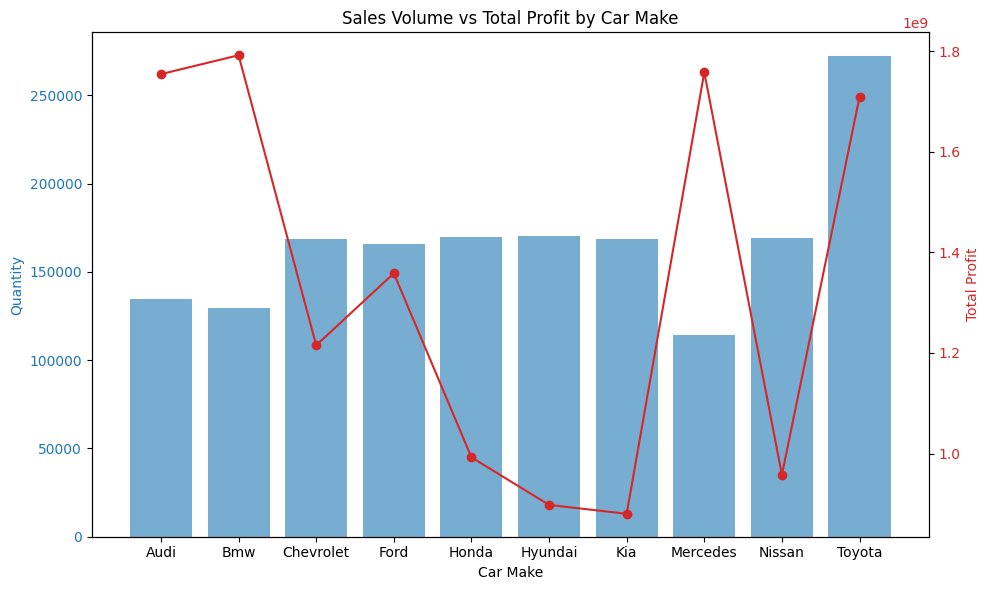

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# sales
color = "tab:blue"
ax1.set_xlabel("Car Make")
ax1.set_ylabel("Quantity", color=color)
ax1.bar(
    make_performance.index,
    make_performance["Quantity"],
    color=color,
    alpha=0.6,
    label="Quantity",
)
ax1.tick_params(axis="y", labelcolor=color)

# profits
ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel("Total Profit", color=color)
ax2.plot(
    make_performance.index,
    make_performance["Total_Profit"],
    color=color,
    marker="o",
    label="Total Profit",
)
ax2.tick_params(axis="y", labelcolor=color)

plt.title("Sales Volume vs Total Profit by Car Make")
fig.tight_layout()
plt.show()

<b>Insight:</b> 


Toyota achieves the highest sales volume (252,164 cars sold) but lags behind premium brands like BMW, Audi, and Mercedes in total profit. This suggests that Toyota relies on high-volume, lower-margin sales, while luxury brands generate higher profits per unit despite selling fewer cars.

### Trend of Average Profit over Time

In [ ]:
profit_trend = df.groupby(df["Date"].dt.to_period("M"))["Profit"].mean().reset_index()
profit_trend["Date"] = profit_trend["Date"].dt.to_timestamp()

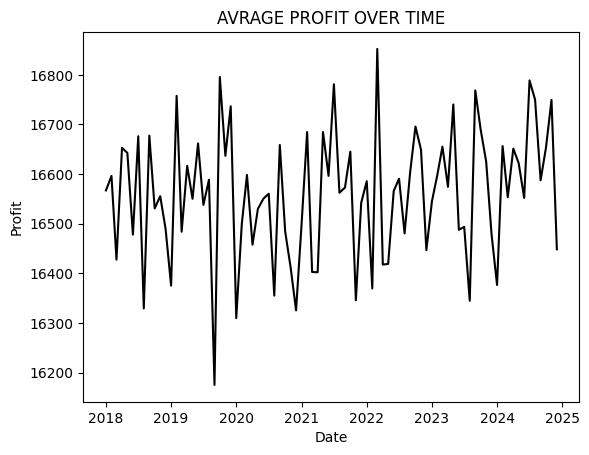

In [ ]:
sns.lineplot(x="Date", y="Profit", data=profit_trend, color="black")
plt.title("AVRAGE PROFIT OVER TIME")
plt.show()

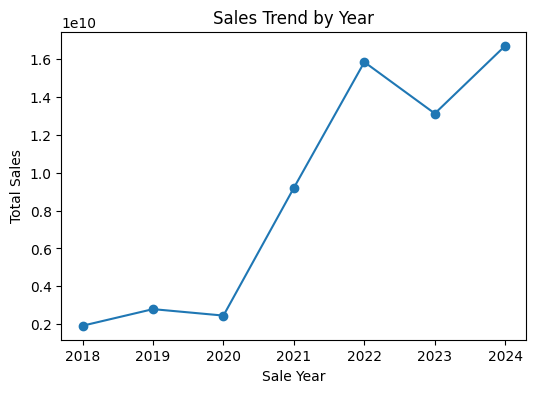

In [ ]:
df.groupby("Sale Year")["Sale Price"].sum().plot(
    kind="line", marker="o", figsize=(6, 4)
)
plt.title("Sales Trend by Year")
plt.ylabel("Total Sales")
plt.show()

<b>The Core Business Question</b>

This leads us to a critical question in business analysis: Why are sales growing exponentially while profits remain flat and volatile?

There are several potential explanations for this scenario, and the data invites a deeper investigation:

- Increasing Costs: The cost of acquiring these sales (Cost of cars Sold, marketing expenses, wages, etc.) might be rising at the same rate as or even faster than sales revenue. You are selling more, but you are also spending more, resulting in a stagnant or shrinking profit margin.
Pricing and Discounting Strategy: The company might be relying on heavy discounts or aggressive pricing strategies to drive sales volume. While this boosts total revenue (Sales), it erodes the profit made on each individual transaction.

- Product Mix Shift: The company may have started selling a higher volume of low-margin products.This would increase overall sales figures but would not contribute equally to profitability.
Costs of Scaling: Rapid growth often requires significant investment in infrastructure, new employees, and technology. These scaling costs can consume profits in the short term.

- Proposed Solution: A Profitability Enhancement Strategy
The data reveals a clear disconnect between revenue growth and profitability. To address this, a strategic initiative focused on margin improvement is essential. The goal is to ensure that the impressive sales growth translates into healthy profit growth.
Here is a proposed multi-step solution:

<b>Phase 1:</b> Diagnostic Analysis (Identify the "Why")
Conduct a Full Cost Structure Analysis: Break down all costs into fixed, variable, and semi-variable categories.Analyze how each cost component has trended over time in relation to sales growth. This will pinpoint exactly where costs are increasing.
Analyze Profitability by Product/Service: Don't just look at overall profit. Calculate the gross margin for each product line or service category.This will likely reveal that some products are highly profitable while others may even be loss leaders.
Review Pricing and Discounting Policies: Analyze the impact of promotions and discounts on both sales volume and net profit margin. Evaluate if the increase in volume justifies the reduction in margin.

<b>Phase 2:</b> Strategic Actions (Address the Issues)
Optimize the Product Mix: Strategically promote and incentivize the sale of high-margin products.Consider bundling high-margin items with lower-margin bestsellers to improve the overall profitability of a transaction.It may also be necessary to phase out or re-price products that consistently underperform.
Implement Strategic Cost Management: Based on the cost analysis, identify areas for operational efficiency. This could involve renegotiating supplier contracts, automating manual tasks to reduce labor costs, or optimizing inventory management to reduce holding costs.
Refine the Pricing Strategy: Move away from a purely volume-driven sales approach. Implement a value-based pricing strategy that reflects the quality and benefits of your products. Consider creating pricing tiers (e.g., good/better/best) to capture a wider range of customers while protecting margins.

###  Monthly Model Popularity Trends

- Observe how demand for specific models fluctuates throughout the year.
  
- Actionable Improvement: Plan targeted marketing and inventory stocking for specific models ahead of their peak demand months.

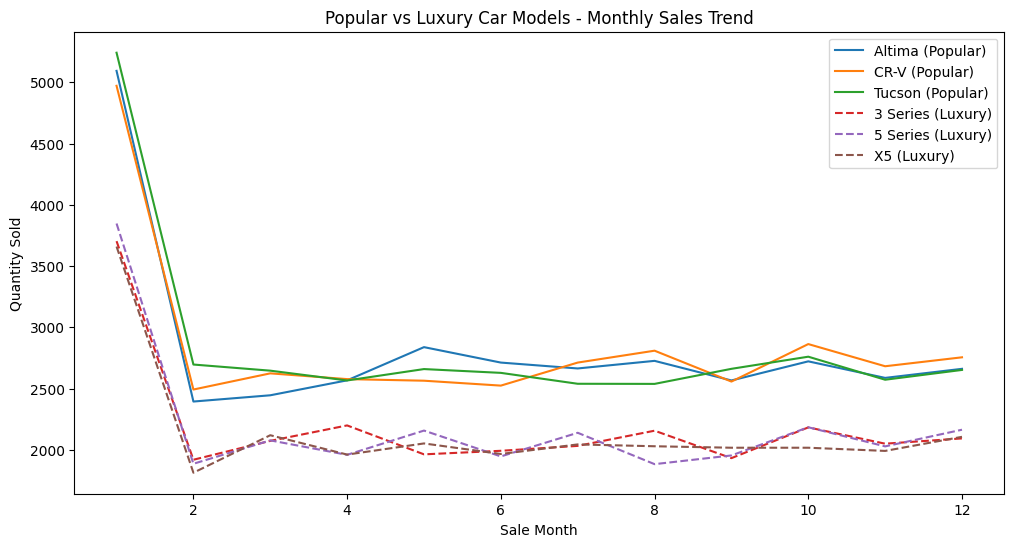

In [ ]:
monthly_model_trend = pd.pivot_table(
    df,
    values="Quantity",
    index="Sale Month Num",
    columns="Car Model",
    aggfunc="sum",
    fill_value=0,
)

popular_models = ["Altima", "CR-V", "Tucson"]
luxury_models = ["3 Series", "5 Series", "X5"]

plt.figure(figsize=(12, 6))

# Popular models (Solid lines)
for model in popular_models:
    plt.plot(
        monthly_model_trend.index,
        monthly_model_trend[model],
        label=f"{model} (Popular)",
        linestyle="-",
    )

# Luxury models (Dashed lines)
for model in luxury_models:
    plt.plot(
        monthly_model_trend.index,
        monthly_model_trend[model],
        label=f"{model} (Luxury)",
        linestyle="--",
    )

plt.title("Popular vs Luxury Car Models - Monthly Sales Trend")
plt.xlabel("Sale Month")
plt.ylabel("Quantity Sold")
plt.legend()
plt.show()

<b>Insight:</b> 

##### When comparing popular models (Altima, CR-V, Tucson) with luxury models (3 Series, 5 Series, X5):

- Popular models consistently outsell luxury models across almost all months  indicating that affordability and demand for practical vehicles drive higher sales volumes.

- Luxury models show more stable but lower sales, reflecting their niche market and higher pricing, which makes them less frequently purchased compared to mass-market cars.

- Seasonal fluctuations are more visible in popular models (larger spikes and dips in sales), while luxury models remain relatively flat, suggesting that popular cars are more influenced by consumer trends, promotions, or seasonal demand.

- This insight suggests that dealerships should focus promotions and inventory planning more aggressively on popular models, while luxury models can be positioned with premium marketing strategies targeting a stable but smaller audience.

###  Season & Car Make Profitability
- Understand which car brands are most profitable during which seasons.
- Actionable Improvement: Time promotional campaigns and inventory orders for specific brands to align with their most profitable seasons.

In [ ]:
season_make_profit = pd.pivot_table(
    df, values="Profit", index="Season", columns="Car Make", aggfunc="sum", fill_value=0
)
print(season_make_profit)

Car Make          Audi           Bmw     Chevrolet          Ford  \
Season                                                             
Fall      4.145289e+08  4.235266e+08  2.822550e+08  3.159498e+08   
Spring    5.265497e+08  5.395083e+08  3.660617e+08  4.090847e+08   
Summer    4.094371e+08  4.160519e+08  2.854890e+08  3.218783e+08   
Winter    4.041986e+08  4.131491e+08  2.815182e+08  3.116688e+08   

Car Make         Honda       Hyundai           Kia      Mercedes  \
Season                                                             
Fall      2.349773e+08  2.106611e+08  2.043282e+08  4.070306e+08   
Spring    2.924969e+08  2.646568e+08  2.620906e+08  5.275649e+08   
Summer    2.343944e+08  2.121645e+08  2.074286e+08  4.131353e+08   
Winter    2.305695e+08  2.103415e+08  2.062894e+08  4.107218e+08   

Car Make        Nissan        Toyota  
Season                                
Fall      2.265986e+08  3.959853e+08  
Spring    2.856231e+08  5.100113e+08  
Summer    2.261011e+08  4.

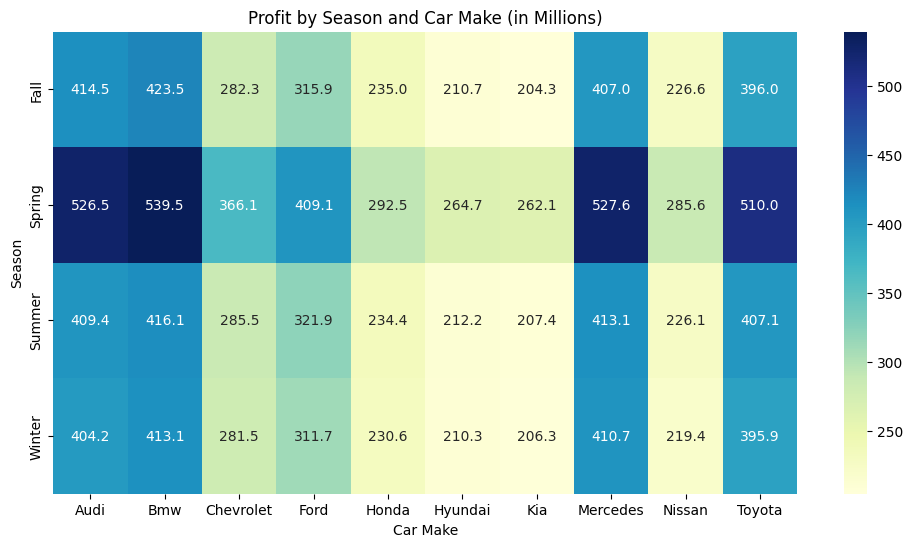

In [ ]:
plt.figure(figsize=(12, 6))
season_make_profit_million = season_make_profit / 1e6

sns.heatmap(season_make_profit_million, annot=True, fmt=".1f", cmap="YlGnBu")

plt.title("Profit by Season and Car Make (in Millions)")
plt.ylabel("Season")
plt.xlabel("Car Make")
plt.show()

<b>Insight:</b> 

- Spring is the peak season across almost all car brands, with significantly higher profits compared to other seasons.

- Premium brands like BMW, Audi, and Mercedes see strong seasonal gains in Spring, indicating higher demand for luxury vehicles during that time.

- Mass-market brands like Toyota, Ford, and Chevrolet also peak in Spring, but the increase is slightly less sharp than premium brands.

- Winter and Fall are the weakest seasons, where sales and profits drop consistently across all brands.

<b>Recommendation</b> for the dealership: Focus marketing campaigns and inventory buildup in Spring, especially for premium cars, while preparing promotions/discounts in Winter and Fall to stimulate demand.